In [63]:
# loading dependencies

from datetime import datetime
from datetime import timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [64]:
# load data

kpi_path = 'C:/Users/ywa/OneDrive - Stifterverband/Dokumente/Data/KPI Table/KPI_ts.xlsx'

kpi_df = pd.read_excel(kpi_path)

kpi_df.set_index('Date', inplace = True)

print(kpi_df.shape)

kpi_df.head()


(85, 12)


,Unique_Visitors,User_Portal,User_Moodle,Enrolments_Moodle,CoP_Moodle,RoA_Moodle,Video_Views_YouTube,Podcast_MedKI,Podcast_Daten,Podcast_Journalismus,Podcast_KIKapiert,Podcast_Sum
Date,,,,,,,,,,,,
2020-06-01,na,11.0,na,na,na,na,287.0,na,na,na,na,na
2020-07-01,na,266.0,na,na,na,na,306.0,na,na,na,na,na
2020-08-01,na,565.0,na,na,na,na,739.0,na,na,na,na,na
2020-09-01,1872,734.0,na,na,na,na,900.0,na,na,na,na,na
2020-10-01,6038,1047.0,na,na,na,na,1108.0,na,na,na,na,na


In [65]:
# replace 'na' with NaNs

cols = ['Unique_Visitors', 'User_Moodle', 'Enrolments_Moodle', 'CoP_Moodle', 'RoA_Moodle', 'Podcast_MedKI', 'Podcast_Daten', 'Podcast_Journalismus', 'Podcast_KIKapiert', 'Podcast_Sum']

for col in cols:
    kpi_df.loc[kpi_df[col] == 'na', col] = np.nan



In [66]:
# check_nans 

print(kpi_df.shape)

kpi_df.isna().sum()

(85, 12)


Unique_Visitors         13
User_Portal             10
User_Moodle             48
Enrolments_Moodle       48
CoP_Moodle              49
RoA_Moodle              49
Video_Views_YouTube     10
Podcast_MedKI           41
Podcast_Daten           41
Podcast_Journalismus    41
Podcast_KIKapiert       41
Podcast_Sum             41
dtype: int64

* the variable "Podcast_Sum" will only be used for plotting, it will not be used as a feature, since the prediction for the podcasts will be done separately

In [67]:
# create prediction dataframes

unique_visitors = kpi_df[['Unique_Visitors']]

user_portal = kpi_df[['User_Portal']]

user_moodle = kpi_df[['User_Moodle']]

enrol_moodle = kpi_df[['Enrolments_Moodle']]

cop_moodle = kpi_df[['CoP_Moodle']]

roa_moodle = kpi_df[['RoA_Moodle']]

video_youtube = kpi_df[['Video_Views_YouTube']]

podcast_med = kpi_df[['Podcast_MedKI']]

podcast_daten = kpi_df[['Podcast_Daten']]

podcast_journal = kpi_df[['Podcast_Journalismus']]

podcast_kapiert = kpi_df[['Podcast_KIKapiert']]


In [68]:
# drop NaNs

unique_visitors.dropna(inplace = True)

user_portal.dropna(inplace = True)

user_moodle.dropna(inplace = True)

enrol_moodle.dropna(inplace = True)

cop_moodle.dropna(inplace = True)

roa_moodle.dropna(inplace = True)

video_youtube.dropna(inplace = True)

podcast_med.dropna(inplace = True)

podcast_daten.dropna(inplace = True)

podcast_journal.dropna(inplace = True)

podcast_kapiert.dropna(inplace = True)

C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\4108785711.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_visitors.dropna(inplace = True)
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\4108785711.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_portal.dropna(inplace = True)
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\4108785711.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_moodle.dropna(inplace = Tru

In [69]:
# backset testing slices --> all data points before 2026-08-01

# create prediction dataframes

unique_visitors_backtest = unique_visitors.loc[: '2026-08-01', :]

user_portal_backtest = user_portal.loc[: '2026-08-01', :] 

user_moodle_backtest = user_moodle.loc[: '2026-08-01', :]

enrol_moodle_backtest = enrol_moodle.loc[: '2026-08-01', :]

cop_moodle_backtest = cop_moodle.loc[: '2026-08-01', :]

roa_moodle_backtest = roa_moodle.loc[: '2026-08-01', :]

video_youtube_backtest = video_youtube.loc[: '2026-08-01', :]

podcast_med_backtest = podcast_med.loc[: '2026-08-01', :]

podcast_daten_backtest = podcast_daten.loc[: '2026-08-01', :]

podcast_journal_backtest = podcast_journal.loc[: '2026-08-01', :]

podcast_kapiert_backtest = podcast_kapiert.loc[: '2026-08-01', :]



## Using multiplicative bias (scale factor) instead of additive --> 3rd model

### Seasonal factor calculation for the main algorithm

In [70]:
# seasonal effects
# As the growth rate in semester-start months (April, October) 
# and semester break months (July, August, September, Febuary, March) are different

def fit_monthly_seasonality(series: pd.Series, shrink_k: float = 4.0) -> pd.Series:
    """
    Returns a 12-length Series indexed by month (1..12) with shrunk seasonal effects in growth space.
    """
    s = series.dropna().sort_index()
    s.index = pd.to_datetime(s.index)

    r = s.pct_change().dropna()
    overall = r.median()

    by_m = r.groupby(r.index.month)
    med = by_m.median()
    n = by_m.size()

    raw = (med - overall).reindex(range(1, 13)).fillna(0.0)
    n = n.reindex(range(1, 13)).fillna(0)

    lam = n / (n + shrink_k)   # shrink factor
    seasonal = raw * lam
    return seasonal


### Main algorithm

In [71]:
# updated algorithm considering bias, weight and decay
#import numpy as np
#import pandas as pd
#from datetime import datetime
#from dateutil.relativedelta import relativedelta

def moving_average_scale(series, date_of_interest, span_years=3, w_year=0.4, w_3m=0.3, w_1m=0.2,decay=0.7, seasonal = None):
    """
    Enhanced weighted moving-average predictor with bias and momentum terms.
    
    The function calculates the expected value of a given time series at a specific 
    date based on its historical percentage changes from previous years and months.

    Parameters:
    ----------
    series : pd.Series
        A pandas Series representing the time series data. The index should be 
        datetime-like (YYYY-MM-DD format), and the values should be numerical.

    date_of_interest : str
        A string representing the date (YYYY-MM-DD) for which the prediction is made.

    span : int
        The number of years to look back for historical trends.

    w_year : float
        The weight applied to the historical yearly percentage change.

    w_3m : float
        The weight applied to changes from the past three month.
        
    w_1m : float
        The weight applied to changes from the past one month.        

    Returns:
    -------
    float
        The predicted value of the series for the given `date_of_interest`.

    Notes:
    ------
    - The function calculates percentage changes in the series.
    - It considers both past years' trends and recent months' trends.
    - The prediction is computed using a weighted sum with bias and momentum
    """

    series = series.sort_index()
    series_pct = series.pct_change().dropna()

    doi = pd.to_datetime(date_of_interest).normalize()
    prev_month = doi - relativedelta(months=1)

    # --- yearly component ---
    year_dates = [
        doi - relativedelta(years=y) + relativedelta(months=1)
        for y in range(1, span_years + 1)
    ]
    year_rates = series_pct.reindex(year_dates).dropna()

    if len(year_rates) > 0:
        year_weights = np.exp(-decay * np.arange(len(year_rates)))
        year_weights /= year_weights.sum()
        r_year = np.sum(year_rates.values * year_weights)
    else:
        r_year = 0.0

    # --- short-term components ---
    r_1m = series_pct.loc[: prev_month].iloc[-1]

    last_3m = [
        doi - relativedelta(months=m) for m in range(1, 4)
    ]
    r_3m_vals = series_pct.reindex(last_3m).dropna()
    r_3m = r_3m_vals.mean() if len(r_3m_vals) > 0 else 0.0

    # --- prediction ---
    base = series.loc[: prev_month].iloc[-1]
    if pd.isna(base):
        raise KeyError(f"Previous month {prev_month.date()} not in series index.")
    growth = w_year * r_year + w_3m * r_3m + w_1m * r_1m
    
    if seasonal is not None:
        growth += float(seasonal.get(doi.month, 0.0))

    pred = base * (1 + growth)
    return pred

### Function for comparing with the old method (Function: moving_average_plus)

In [72]:
# convert to bias calculator

def bias_calculator(df):
    errors = []

    # only slice the ts that is outside the backtest time stamps (other wise the pct will be calculated)

    df_copy = df.copy().iloc[:, 0]

    for t in backtest['date']:
        prev = t - relativedelta(month = 1)
    
        train = df_copy.loc[: prev]
    
        y_true = df_copy.reindex([t]).iloc[0]
    
        if train.empty or pd.isna(y_true):
            continue
        y_hat = moving_average_plus(train, t.strftime('%Y-%m-%d'), span_years = 3, w_year=0.4, w_3m=0.3, w_1m=0.2, bias=0.0, decay=0.7)
        errors.append(y_hat - y_true)

    avg_errors = np.mean(errors)
    
    return avg_errors, errors

### RMSE function for backtesting

In [73]:
# define RMSE function

def rmse(pred, true, df):
    squareError = ((pred - true) ** 2).sum()
    meanSError = squareError / len(df)
    rmseValue = math.sqrt(meanSError)
    return rmseValue
    

In [74]:
# plotting function

def plot_forecast(origin_ts, pred_ts, title):
    plt.figure(figsize = (10, 6))
    plt.plot(origin_ts, label = 'current', color = '#2991BA')
    plt.plot(pred_ts, label = 'prediction', color = '#84A6B0', linestyle = 'dotted' )
    plt.title(title)
    plt.legend()
    plt.show()

### Prepare dataframe of dates

In [75]:
# predict on the certain section of data --> to backtest (for testing)

#'2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',

backtest = pd.DataFrame({'date': [ '2025-12-01', '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01', '2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01'], 'values' : [0] * 9})

backtest['date'] = pd.to_datetime(backtest['date'])

# aim dates (for prediction new)

pred_moving_average = pd.DataFrame({'date': ['2026-09-01', '2026-10-01', '2026-11-01', '2026-12-01', '2027-01-01', '2027-02-01', '2027-03-01'], 'values' : [0] * 7})

pred_moving_average['date'] = pd.to_datetime(pred_moving_average['date'])

### Backtest evaluation (HPO)
* the back test date should not take to the lastest date it should leave room for true values for testing

In [76]:
# predict on the backtesting set

# unique visitors portal
# calculate seasonality

unique_visitors_backtest = unique_visitors.loc[: '2025-11-01', :]

unique_visitors_seasonal_backtest = fit_monthly_seasonality(unique_visitors_backtest['Unique_Visitors'], shrink_k = 6)


for d in backtest['date']:
    pred = moving_average_scale(unique_visitors_backtest['Unique_Visitors'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.1, w_3m= 0.25, w_1m= 0.3, decay=0.85, seasonal = unique_visitors_seasonal_backtest)
    unique_visitors_backtest.loc[d] = pred
    
unique_visitors_backtest['Unique_Visitors'] = [round(x) for x in unique_visitors_backtest['Unique_Visitors']]

unique_visitors_backtest_join = unique_visitors.loc['2025-12-01' : , :]

unique_visitors_backtest = unique_visitors_backtest.join(unique_visitors_backtest_join, rsuffix = '_true')


# calculate RMSE

unique_visitors_backtest['error'] = unique_visitors_backtest['Unique_Visitors_true'] - unique_visitors_backtest['Unique_Visitors']

rmse_unique_visitors_backtest = rmse(unique_visitors_backtest['Unique_Visitors'], unique_visitors_backtest['Unique_Visitors_true'], unique_visitors_backtest) 

print(rmse_unique_visitors_backtest)

unique_visitors_backtest.tail(15)



17289.33161382411


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\474436253.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

,Unique_Visitors,Unique_Visitors_true,error
Date,,,
2025-06-01,2023372,NaN,NaN
2025-07-01,2080426,NaN,NaN
2025-08-01,2136765,NaN,NaN
2025-09-01,2184258,NaN,NaN
2025-10-01,2241825,NaN,NaN
2025-11-01,2259723,NaN,NaN
2025-12-01,2284568,2284837,269
2026-01-01,2309488,2309136,-352
2026-02-01,2337602,2341292,3690


In [77]:
# user portal

user_portal_backtest = user_portal.loc[: '2025-11-01', :] 

user_portal_seasonal_backtest = fit_monthly_seasonality(user_portal_backtest['User_Portal'], shrink_k = 6)


for d in backtest['date']:
    pred = moving_average_scale(user_portal_backtest['User_Portal'], d.strftime('%Y-%m-%d'), span_years= 4, w_year= 0.3, w_3m= 0.4, w_1m= 0.25, decay= 0.7, seasonal = user_portal_seasonal_backtest)
    user_portal_backtest.loc[d] = pred
    
user_portal_backtest['User_Portal'] = [round(x) for x in user_portal_backtest['User_Portal']]

user_portal_backtest_join = user_portal.loc['2025-12-01' : , :]

user_portal_backtest = user_portal_backtest.join(user_portal_backtest_join, rsuffix = '_true')


# calculate RMSE

user_portal_backtest['error'] = user_portal_backtest['User_Portal_true'] - user_portal_backtest['User_Portal']

rmse_user_portal_backtest = rmse(user_portal_backtest['User_Portal_true'], user_portal_backtest['User_Portal'], user_portal_backtest) 

print(rmse_user_portal_backtest)

user_portal_backtest


1740.7452848325245


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\1207830891.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_portal_backtest.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\1207830891.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_portal_backtest.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\1207830891.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_portal_backtest.loc[d] = pre

,User_Portal,User_Portal_true,error
Date,,,
2020-06-01,11,NaN,NaN
2020-07-01,266,NaN,NaN
2020-08-01,565,NaN,NaN
2020-09-01,734,NaN,NaN
2020-10-01,1047,NaN,NaN
...,...,...,...
2026-04-01,150353,155956.0,5603.0
2026-05-01,158543,162928.0,4385.0
2026-06-01,165167,169271.0,4104.0


In [78]:
# user moodle

user_moodle_backtest = user_moodle.loc[: '2025-11-01', :]

user_moodle_seasonal_backtest = fit_monthly_seasonality(user_moodle_backtest['User_Moodle'], shrink_k = 6)

for d in backtest['date']:
    pred = moving_average_scale(user_moodle_backtest['User_Moodle'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.25, w_3m= 0.25, w_1m= 0.3, decay=0.7, seasonal = user_moodle_seasonal_backtest)
    user_moodle_backtest.loc[d] = pred
    
user_moodle_backtest['User_Moodle'] = [round(x) for x in user_moodle_backtest['User_Moodle']]

user_moodle_backtest_join = user_moodle.loc['2025-12-01' : , :]

user_moodle_backtest = user_moodle_backtest.join(user_moodle_backtest_join, rsuffix = '_true')


# calculate RMSE

user_moodle_backtest['error'] = user_moodle_backtest['User_Moodle_true'] - user_moodle_backtest['User_Moodle']

rmse_user_moodle_backtest = rmse(user_moodle_backtest['User_Moodle_true'], user_moodle_backtest['User_Moodle'], user_moodle_backtest) 

print(rmse_user_moodle_backtest)

user_moodle_backtest.tail(10)




1403.5606265610447


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3797427155.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

,User_Moodle,User_Moodle_true,error
Date,,,
2025-11-01,63361,NaN,NaN
2025-12-01,69622,68682,-940
2026-01-01,76441,77840,1399
2026-02-01,83538,88360,4822
2026-03-01,91484,93496,2012
2026-04-01,100547,99389,-1158
2026-05-01,108045,106071,-1974
2026-06-01,114439,111763,-2676
2026-07-01,120630,117299,-3331


In [97]:
# enrol moodle

enrol_moodle_backtest = enrol_moodle.loc[: '2025-11-01', :]

enrol_moodle_seasonal_backtest = fit_monthly_seasonality(enrol_moodle_backtest['Enrolments_Moodle'], shrink_k = 6)

for d in backtest['date']:
    pred = moving_average_scale(enrol_moodle_backtest['Enrolments_Moodle'], d.strftime('%Y-%m-%d'), span_years= 4, w_year= 0.25, w_3m= 0.25, w_1m= 0.23, decay=0.7, seasonal = enrol_moodle_seasonal_backtest)
    enrol_moodle_backtest.loc[d] = pred
    
enrol_moodle_backtest['Enrolments_Moodle'] = [round(x) for x in enrol_moodle_backtest['Enrolments_Moodle']]

enrol_moodle_backtest_join = enrol_moodle.loc['2025-12-01' : , :]

enrol_moodle_backtest = enrol_moodle_backtest.join(enrol_moodle_backtest_join, rsuffix = '_true')


# calculate RMSE

enrol_moodle_backtest['error'] = enrol_moodle_backtest['Enrolments_Moodle_true'] - enrol_moodle_backtest['Enrolments_Moodle']

rmse_enrol_moodle_backtest = rmse(enrol_moodle_backtest['Enrolments_Moodle_true'], enrol_moodle_backtest['Enrolments_Moodle'], enrol_moodle_backtest) 

print(rmse_enrol_moodle_backtest)

enrol_moodle_backtest.tail(10)


883.5991814807852


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2173106697.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

,Enrolments_Moodle,Enrolments_Moodle_true,error
Date,,,
2025-11-01,102799,NaN,NaN
2025-12-01,116499,114122,-2377
2026-01-01,130326,127109,-3217
2026-02-01,142575,145141,2566
2026-03-01,155161,156093,932
2026-04-01,170902,169286,-1616
2026-05-01,183747,183366,-381
2026-06-01,194729,195154,425
2026-07-01,205964,206807,843


In [99]:
# cop moodle

cop_moodle_backtest = cop_moodle.loc[: '2025-11-01', :]

cop_moodle_seasonal_backtest = fit_monthly_seasonality(cop_moodle_backtest['CoP_Moodle'], shrink_k = 6)

for d in backtest['date']:
    pred = moving_average_scale(cop_moodle_backtest['CoP_Moodle'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.17, w_3m= 0.18, w_1m= 0.2, decay=0.8, seasonal = cop_moodle_seasonal_backtest)
    cop_moodle_backtest.loc[d] = pred
    
cop_moodle_backtest['CoP_Moodle'] = [round(x) for x in cop_moodle_backtest['CoP_Moodle']]

cop_moodle_backtest_join = cop_moodle.loc['2025-12-01' : , :]

cop_moodle_backtest = cop_moodle_backtest.join(cop_moodle_backtest_join, rsuffix = '_true')


# calculate RMSE

cop_moodle_backtest['error'] = cop_moodle_backtest['CoP_Moodle_true'] - cop_moodle_backtest['CoP_Moodle']

rmse_cop_moodle_backtest = rmse(cop_moodle_backtest['CoP_Moodle_true'], cop_moodle_backtest['CoP_Moodle'], cop_moodle_backtest) 

print(rmse_cop_moodle_backtest)

cop_moodle_backtest.tail(10)



819.8402452781747


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\1613177109.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

,CoP_Moodle,CoP_Moodle_true,error
Date,,,
2025-11-01,18911,NaN,NaN
2025-12-01,21818,21648,-170
2026-01-01,26444,26276,-168
2026-02-01,34406,34861,455
2026-03-01,39195,37309,-1886
2026-04-01,43180,40323,-2857
2026-05-01,46301,43336,-2965
2026-06-01,48396,46702,-1694
2026-07-01,50333,49850,-483


In [103]:
# roa moodle

roa_moodle_backtest = roa_moodle.loc[: '2025-11-01', :]

roa_moodle_seasonal_backtest = fit_monthly_seasonality(roa_moodle_backtest['RoA_Moodle'], shrink_k = 6) 

for d in backtest['date']:
    pred = moving_average_scale(roa_moodle_backtest['RoA_Moodle'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.2, w_3m= 0.25, w_1m= 0.3, decay=0.7, seasonal = roa_moodle_seasonal_backtest)
    roa_moodle_backtest.loc[d] = pred
    
roa_moodle_backtest['RoA_Moodle'] = [round(x) for x in roa_moodle_backtest['RoA_Moodle']]

roa_moodle_backtest_join = roa_moodle.loc['2025-12-01' : , :]

roa_moodle_backtest = roa_moodle_backtest.join(roa_moodle_backtest_join, rsuffix = '_true')


# calculate RMSE

roa_moodle_backtest['error'] = roa_moodle_backtest['RoA_Moodle_true'] - roa_moodle_backtest['RoA_Moodle']

rmse_roa_moodle_backtest = rmse(roa_moodle_backtest['RoA_Moodle_true'], roa_moodle_backtest['RoA_Moodle'], roa_moodle_backtest) 

print(rmse_roa_moodle_backtest)

roa_moodle_backtest.tail(10)


854.3171087027476


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3913907288.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

,RoA_Moodle,RoA_Moodle_true,error
Date,,,
2025-11-01,14024,NaN,NaN
2025-12-01,16213,16114,-99
2026-01-01,18924,19508,584
2026-02-01,22381,25441,3060
2026-03-01,26314,27610,1296
2026-04-01,30304,30063,-241
2026-05-01,33686,32459,-1227
2026-06-01,36732,35177,-1555
2026-07-01,39840,37789,-2051


In [112]:
# youtube video

video_youtube_backtest = video_youtube.loc[: '2025-11-01', :]

video_youtube_seasonal_backtest = fit_monthly_seasonality(video_youtube_backtest['Video_Views_YouTube'], shrink_k = 6)

for d in backtest['date']:
    pred = moving_average_scale(video_youtube_backtest['Video_Views_YouTube'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.07, w_3m= 0.1, w_1m= 0.1, decay=0.9, seasonal = video_youtube_seasonal_backtest)
    video_youtube_backtest.loc[d] = pred
    
video_youtube_backtest['Video_Views_YouTube'] = [round(x) for x in video_youtube_backtest['Video_Views_YouTube']]

video_youtube_backtest_join = video_youtube.loc['2025-12-01' : , :]

video_youtube_backtest = video_youtube_backtest.join(video_youtube_backtest_join, rsuffix = '_true')


# calculate RMSE

video_youtube_backtest['error'] = video_youtube_backtest['Video_Views_YouTube_true'] - video_youtube_backtest['Video_Views_YouTube']

rmse_video_youtube_backtest = rmse(video_youtube_backtest['Video_Views_YouTube_true'], video_youtube_backtest['Video_Views_YouTube'], video_youtube_backtest) 

print(rmse_video_youtube_backtest)

video_youtube_backtest.tail(15)



27222.751619187948


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2561948494.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_youtube_backtest.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2561948494.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_youtube_backtest.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2561948494.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_youtube_backtest.loc[d] = 

,Video_Views_YouTube,Video_Views_YouTube_true,error
Date,,,
2025-06-01,3337522,NaN,NaN
2025-07-01,3378324,NaN,NaN
2025-08-01,3438800,NaN,NaN
2025-09-01,3496588,NaN,NaN
2025-10-01,3559049,NaN,NaN
2025-11-01,3627173,NaN,NaN
2025-12-01,3726261,3685898.0,-40363.0
2026-01-01,3816460,3732781.0,-83679.0
2026-02-01,3831795,3798367.0,-33428.0


In [116]:
# podcast KI medicine

podcast_med_backtest = podcast_med.loc[: '2025-11-01', :]

podcast_med_seasonal_backtest = fit_monthly_seasonality(podcast_med_backtest['Podcast_MedKI'], shrink_k = 6)

for d in backtest['date']:
    pred = moving_average_scale(podcast_med_backtest['Podcast_MedKI'], d.strftime('%Y-%m-%d'), span_years=3, w_year= 0.2, w_3m= 0.20, w_1m= 0.3, decay=0.8, seasonal = podcast_med_seasonal_backtest)
    podcast_med_backtest.loc[d] = pred
    
podcast_med_backtest['Podcast_MedKI'] = [round(x) for x in podcast_med_backtest['Podcast_MedKI']]

podcast_med_backtest_join = podcast_med.loc['2025-12-01' : , :]

podcast_med_backtest = podcast_med_backtest.join(podcast_med_backtest_join, rsuffix = '_true')


# calculate RMSE

podcast_med_backtest['error'] = podcast_med_backtest['Podcast_MedKI_true'] - podcast_med_backtest['Podcast_MedKI']

rmse_podcast_med_backtest = rmse(podcast_med_backtest['Podcast_MedKI_true'], podcast_med_backtest['Podcast_MedKI'], podcast_med_backtest) 

print(rmse_podcast_med_backtest)

podcast_med_backtest.tail(15)


1006.9576816963425


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\4126286955.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

,Podcast_MedKI,Podcast_MedKI_true,error
Date,,,
2025-06-01,54229,NaN,NaN
2025-07-01,55039,NaN,NaN
2025-08-01,55791,NaN,NaN
2025-09-01,56482,NaN,NaN
2025-10-01,57163,NaN,NaN
2025-11-01,57830,NaN,NaN
2025-12-01,58557,58389,-168
2026-01-01,59548,58894,-654
2026-02-01,60549,59451,-1098


In [122]:
# podcast data

podcast_daten_backtest = podcast_daten.loc[: '2025-11-01', :]

podcast_daten_seasonal_backtest = fit_monthly_seasonality(podcast_daten_backtest['Podcast_Daten'], shrink_k = 6)

for d in backtest['date']:
    pred = moving_average_scale(podcast_daten_backtest['Podcast_Daten'], d.strftime('%Y-%m-%d'), span_years=3, w_year= 0.1, w_3m= 0.2, w_1m= 0.3, decay=0.8, seasonal = podcast_daten_seasonal_backtest)
    podcast_daten_backtest.loc[d] = pred
    
podcast_daten_backtest['Podcast_Daten'] = [round(x) for x in podcast_daten_backtest['Podcast_Daten']]

podcast_daten_backtest_join = podcast_daten.loc['2025-12-01' : , :]

podcast_daten_backtest = podcast_daten_backtest.join(podcast_daten_backtest_join, rsuffix = '_true')


# calculate RMSE

podcast_daten_backtest['error'] = podcast_daten_backtest['Podcast_Daten_true'] - podcast_daten_backtest['Podcast_Daten']

rmse_podcast_daten_backtest = rmse(podcast_daten_backtest['Podcast_Daten_true'], podcast_daten_backtest['Podcast_Daten'], podcast_daten_backtest) 

print(rmse_podcast_daten_backtest)

podcast_daten_backtest.tail(15)


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\4014815178.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

97.74596015832434


,Podcast_Daten,Podcast_Daten_true,error
Date,,,
2025-06-01,11734,NaN,NaN
2025-07-01,11969,NaN,NaN
2025-08-01,12283,NaN,NaN
2025-09-01,12590,NaN,NaN
2025-10-01,12811,NaN,NaN
2025-11-01,13033,NaN,NaN
2025-12-01,13205,13268,63
2026-01-01,13341,13413,72
2026-02-01,13506,13576,70


In [128]:
# podcast journalism
podcast_journal_backtest = podcast_journal.loc[: '2025-11-01', :]

podcast_journal_seasonal_backtest = fit_monthly_seasonality(podcast_journal_backtest['Podcast_Journalismus'], shrink_k = 6)

for d in backtest['date']:
    pred = moving_average_scale(podcast_journal_backtest['Podcast_Journalismus'], d.strftime('%Y-%m-%d'), span_years=3, w_year= 0.2, w_3m= 0.2, w_1m= 0.3, decay=0.7, seasonal = podcast_journal_seasonal_backtest)
    podcast_journal_backtest.loc[d] = pred
    
podcast_journal_backtest['Podcast_Journalismus'] = [round(x) for x in podcast_journal_backtest['Podcast_Journalismus']]

podcast_journal_backtest_join = podcast_journal.loc['2025-12-01' : , :]

podcast_journal_backtest = podcast_journal_backtest.join(podcast_journal_backtest_join, rsuffix = '_true')


# calculate RMSE

podcast_journal_backtest['error'] = podcast_journal_backtest['Podcast_Journalismus_true'] - podcast_journal_backtest['Podcast_Journalismus']

rmse_podcast_journal_backtest = rmse(podcast_journal_backtest['Podcast_Journalismus_true'], podcast_journal_backtest['Podcast_Journalismus'], podcast_journal_backtest) 

print(rmse_podcast_journal_backtest)

podcast_journal_backtest.tail(15)


125.27878003585734


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3073189124.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

,Podcast_Journalismus,Podcast_Journalismus_true,error
Date,,,
2025-06-01,5099,NaN,NaN
2025-07-01,5176,NaN,NaN
2025-08-01,5264,NaN,NaN
2025-09-01,5399,NaN,NaN
2025-10-01,5541,NaN,NaN
2025-11-01,5657,NaN,NaN
2025-12-01,5766,5729,-37
2026-01-01,5869,5799,-70
2026-02-01,6013,5864,-149


In [130]:
# podcast KI kapiert

podcast_kapiert_backtest = podcast_kapiert.loc[: '2025-11-01', :]

podcast_kapiert_seasonal_backtest = fit_monthly_seasonality(podcast_kapiert_backtest['Podcast_KIKapiert'], shrink_k = 6)

for d in backtest['date']:
    pred = moving_average_scale(podcast_kapiert_backtest['Podcast_KIKapiert'], d.strftime('%Y-%m-%d'), span_years=3, w_year= 0.05, w_3m= 0.2, w_1m= 0.2, decay=0.7, seasonal = podcast_kapiert_seasonal_backtest)
    podcast_kapiert_backtest.loc[d] = pred
    
podcast_kapiert_backtest['Podcast_KIKapiert'] = [round(x) for x in podcast_kapiert_backtest['Podcast_KIKapiert']]

podcast_kapiert_backtest_join = podcast_kapiert.loc['2025-12-01' : , :]

podcast_kapiert_backtest = podcast_kapiert_backtest.join(podcast_kapiert_backtest_join, rsuffix = '_true')


# calculate RMSE

podcast_kapiert_backtest['error'] = podcast_kapiert_backtest['Podcast_KIKapiert_true'] - podcast_kapiert_backtest['Podcast_KIKapiert']

rmse_podcast_kapiert_backtest = rmse(podcast_kapiert_backtest['Podcast_KIKapiert_true'], podcast_kapiert_backtest['Podcast_KIKapiert'], podcast_kapiert_backtest) 

print(rmse_podcast_kapiert_backtest)

podcast_kapiert_backtest.tail(15)


333.0640806484269


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3738975199.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

,Podcast_KIKapiert,Podcast_KIKapiert_true,error
Date,,,
2025-06-01,61699,NaN,NaN
2025-07-01,64268,NaN,NaN
2025-08-01,66791,NaN,NaN
2025-09-01,68925,NaN,NaN
2025-10-01,70427,NaN,NaN
2025-11-01,71917,NaN,NaN
2025-12-01,72875,73230,355
2026-01-01,73521,74442,921
2026-02-01,75663,75946,283


### Prediction on the TS

In [21]:
unique_visitors

,Unique_Visitors
Date,
2020-09-01,1872
2020-10-01,6038
2020-11-01,11157
2020-12-01,14858
2021-01-01,18350
...,...
2026-07-01,2598155
2026-08-01,2645216
2026-09-01,2680784


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3511642096.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2534131.0939726783' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  unique_visitors.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3511642096.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_visitors.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3511642096.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vi

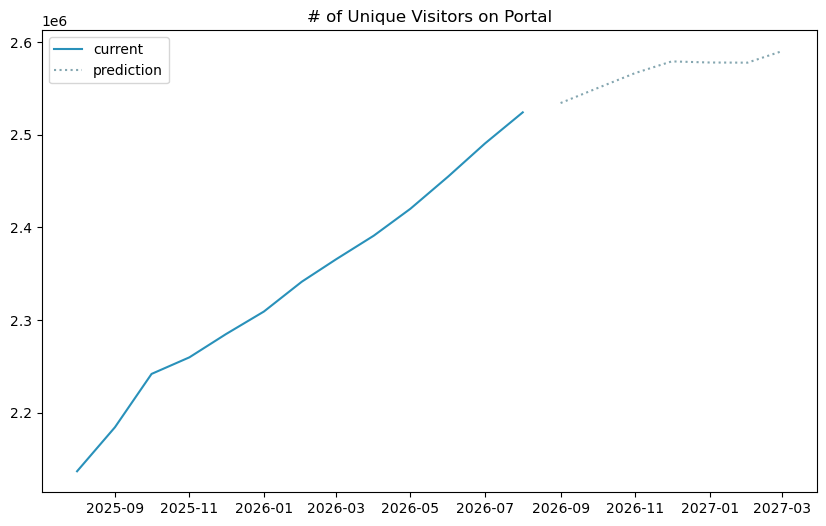

,Unique_Visitors
Date,
2026-08-01,2524079
2026-09-01,2534131
2026-10-01,2550137
2026-11-01,2566438
2026-12-01,2579057
2027-01-01,2577864
2027-02-01,2577690
2027-03-01,2589979


In [132]:
# unique visitors portal
# calculate seasonality

unique_visitors_seasonal = fit_monthly_seasonality(unique_visitors['Unique_Visitors'], shrink_k = 6)

# prediction with scale factor

for d in pred_moving_average['date']:
    pred = moving_average_scale(unique_visitors['Unique_Visitors'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.1, w_3m= 0.25, w_1m= 0.3, decay=0.85, seasonal = unique_visitors_seasonal)
    unique_visitors.loc[d] = pred
    
unique_visitors['Unique_Visitors'] = [round(x) for x in unique_visitors['Unique_Visitors']]

# plotting
plot_forecast(unique_visitors.loc['2025-08-01' : '2026-08-01'], unique_visitors.loc['2026-09-01' : ], '# of Unique Visitors on Portal')

unique_visitors.loc['2026-08-01' : ]



C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2714651364.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_portal.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2714651364.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_portal.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2714651364.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_portal.loc[d] = pred
C:\Users\ywa\AppData\Loca

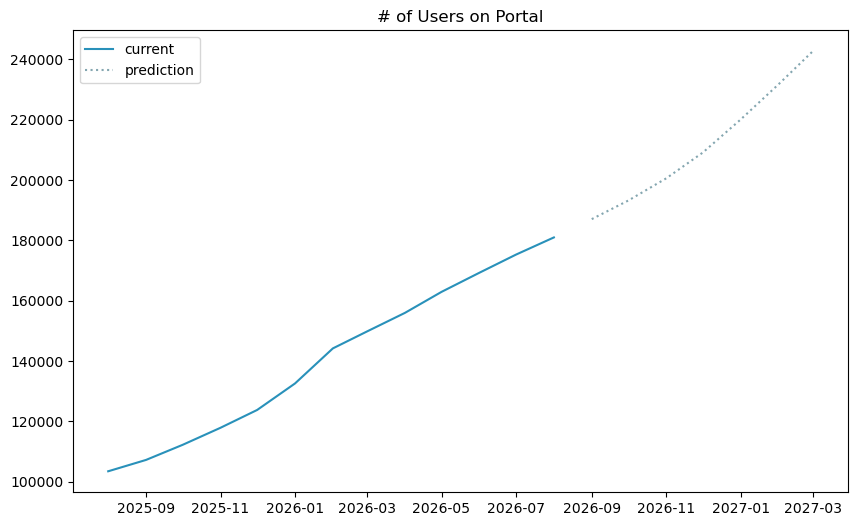

,User_Portal
Date,
2026-08-01,180980
2026-09-01,187052
2026-10-01,193229
2026-11-01,200574
2026-12-01,209136
2027-01-01,220107
2027-02-01,231766
2027-03-01,242719


In [133]:
# user portal
# calculate seasonality

user_portal_seasonal = fit_monthly_seasonality(user_portal['User_Portal'], shrink_k = 6)

# prediction with scale factor

for d in pred_moving_average['date']:
    pred = moving_average_scale(user_portal['User_Portal'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.3, w_3m= 0.4, w_1m= 0.25, decay=0.7, seasonal = user_portal_seasonal)
    user_portal.loc[d] = pred
    
user_portal['User_Portal'] = [round(x) for x in user_portal['User_Portal']]


# plotting
plot_forecast(user_portal.loc['2025-08-01' : '2026-08-01'], user_portal.loc['2026-09-01' : ], '# of Users on Portal')

user_portal.loc['2026-08-01' : ]


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\1333849705.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

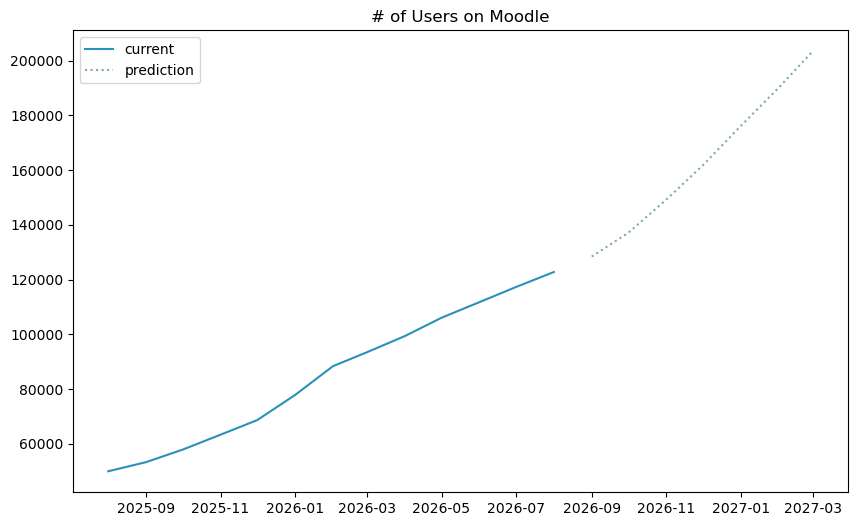

,User_Moodle
Date,
2026-08-01,122783
2026-09-01,128409
2026-10-01,137118
2026-11-01,149192
2026-12-01,161759
2027-01-01,176086
2027-02-01,190039
2027-03-01,203392


In [134]:
# user moodle

user_moodle_seasonal = fit_monthly_seasonality(user_moodle['User_Moodle'], shrink_k = 6)

for d in pred_moving_average['date']:
    pred = moving_average_scale(user_moodle['User_Moodle'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.25, w_3m= 0.25, w_1m= 0.3, decay=0.7, seasonal = user_moodle_seasonal)
    user_moodle.loc[d] = pred
    
user_moodle['User_Moodle'] = [round(x) for x in user_moodle['User_Moodle']]

# plotting
plot_forecast(user_moodle.loc['2025-08-01' : '2026-08-01'], user_moodle.loc['2026-09-01' : ], '# of Users on Moodle')

user_moodle.loc['2026-08-01' : ]



C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2873278010.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

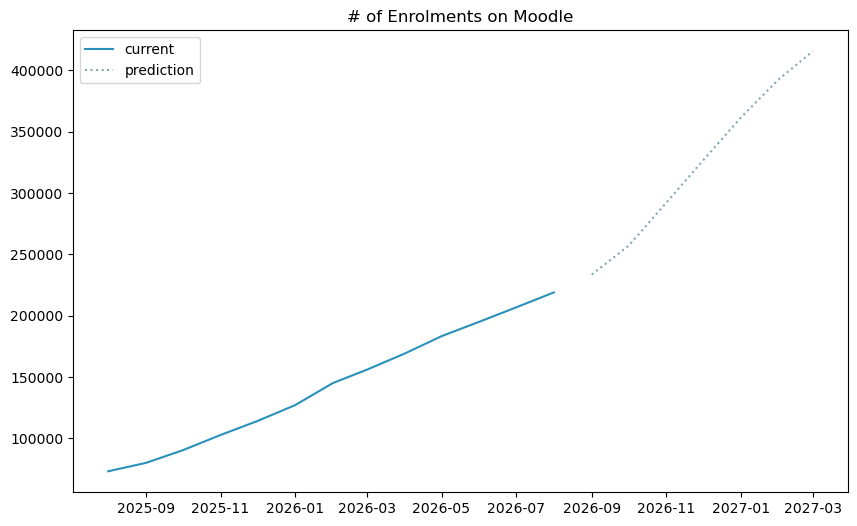

,Enrolments_Moodle
Date,
2026-08-01,219063
2026-09-01,233620
2026-10-01,256910
2026-11-01,292145
2026-12-01,326488
2027-01-01,361476
2027-02-01,392689
2027-03-01,415665


In [135]:
# enrol moodle

enrol_moodle_seasonal = fit_monthly_seasonality(enrol_moodle['Enrolments_Moodle'], shrink_k = 6)

for d in pred_moving_average['date']:
    pred = moving_average_scale(enrol_moodle['Enrolments_Moodle'], d.strftime('%Y-%m-%d'), span_years= 4, w_year= 0.25, w_3m= 0.25, w_1m= 0.23, decay=0.7, seasonal = enrol_moodle_seasonal)
    enrol_moodle.loc[d] = pred
    
enrol_moodle['Enrolments_Moodle'] = [round(x) for x in enrol_moodle['Enrolments_Moodle']]

# plotting
plot_forecast(enrol_moodle.loc['2025-08-01' : '2026-08-01'], enrol_moodle.loc['2026-09-01' : ], '# of Enrolments on Moodle')

enrol_moodle.loc['2026-08-01' : ]


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\67478767.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retu

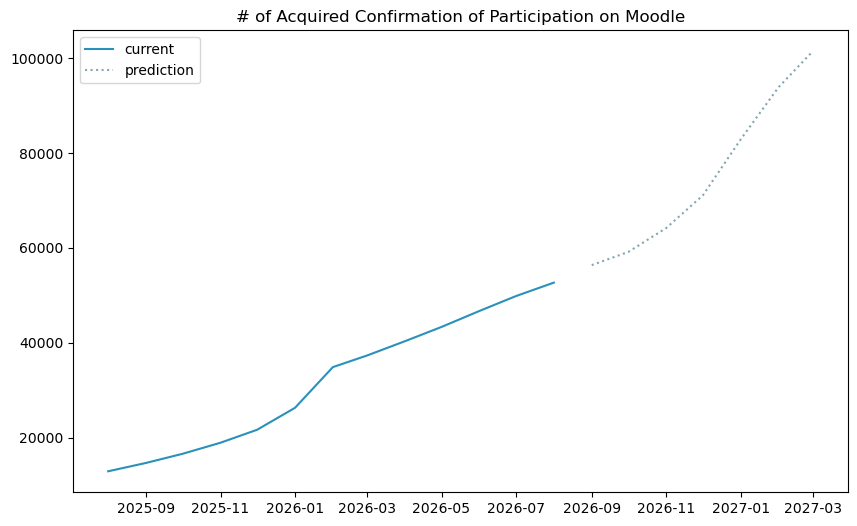

,CoP_Moodle
Date,
2026-08-01,52686
2026-09-01,56374
2026-10-01,59162
2026-11-01,64205
2026-12-01,71094
2027-01-01,82902
2027-02-01,93908
2027-03-01,101487


In [136]:
# cop moodle

cop_moodle_seasonal = fit_monthly_seasonality(cop_moodle['CoP_Moodle'], shrink_k = 6)

for d in pred_moving_average['date']:
    pred = moving_average_scale(cop_moodle['CoP_Moodle'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.17, w_3m= 0.18, w_1m= 0.2, decay=0.8, seasonal = cop_moodle_seasonal)
    cop_moodle.loc[d] = pred
    
cop_moodle['CoP_Moodle'] = [round(x) for x in cop_moodle['CoP_Moodle']]

# plotting
plot_forecast(cop_moodle.loc['2025-08-01' : '2026-08-01'], cop_moodle.loc['2026-09-01' : ], '# of Acquired Confirmation of Participation on Moodle')

cop_moodle.loc['2026-08-01' : ]

C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2070070581.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

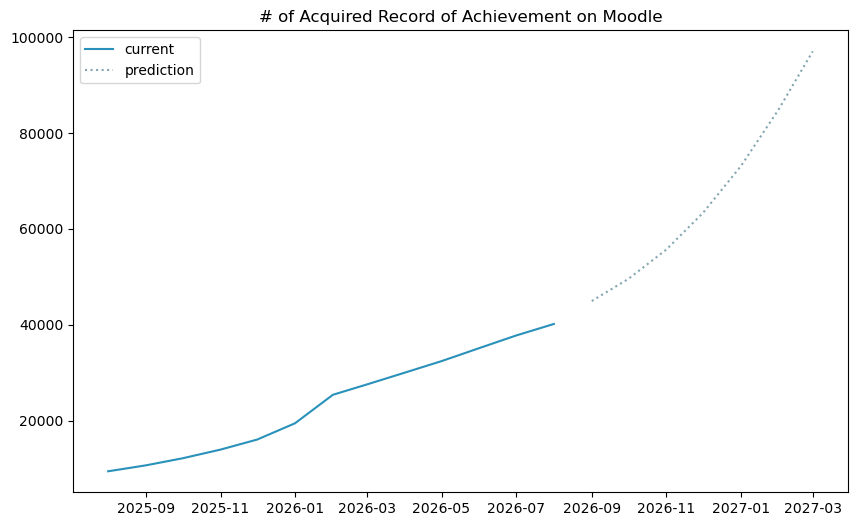

,RoA_Moodle
Date,
2026-08-01,40199
2026-09-01,44978
2026-10-01,49587
2026-11-01,55681
2026-12-01,63317
2027-01-01,73040
2027-02-01,84861
2027-03-01,97016


In [137]:
# roa moodle

roa_moodle_seasonal = fit_monthly_seasonality(roa_moodle['RoA_Moodle'], shrink_k = 6)

for d in pred_moving_average['date']:
    pred = moving_average_scale(roa_moodle['RoA_Moodle'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.2, w_3m= 0.25, w_1m= 0.3, decay=0.7, seasonal = roa_moodle_seasonal)
    roa_moodle.loc[d] = pred
    
roa_moodle['RoA_Moodle'] = [round(x) for x in roa_moodle['RoA_Moodle']]

# plotting
plot_forecast(roa_moodle.loc['2025-08-01' : '2026-08-01'], roa_moodle.loc['2026-09-01' : ], '# of Acquired Record of Achievement on Moodle')

roa_moodle.loc['2026-08-01' : ]

C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3770523677.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_youtube.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3770523677.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_youtube.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3770523677.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_youtube.loc[d] = pred
C:\Users\ywa\AppData\L

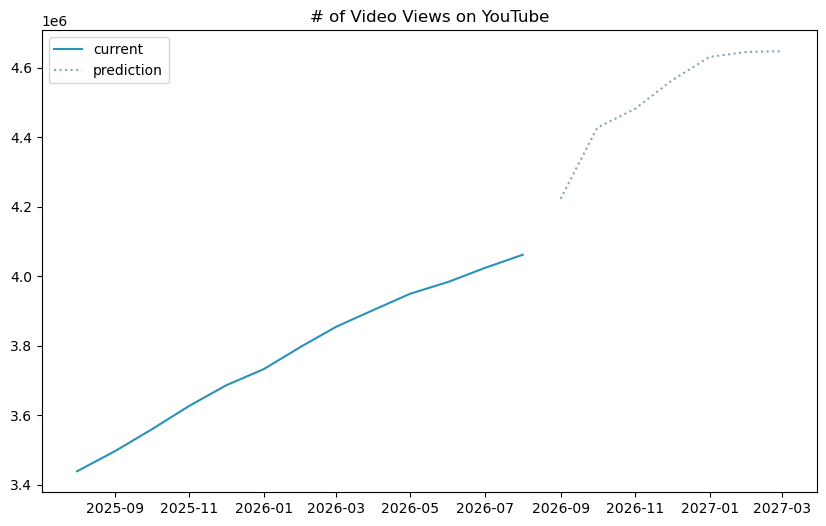

,Video_Views_YouTube
Date,
2026-08-01,4061552
2026-09-01,4222448
2026-10-01,4426974
2026-11-01,4481115
2026-12-01,4562683
2027-01-01,4630575
2027-02-01,4645043
2027-03-01,4646715


In [138]:
# Video YouTube

video_youtube_seasonal = fit_monthly_seasonality(video_youtube['Video_Views_YouTube'], shrink_k = 6)

for d in pred_moving_average['date']:
    pred = moving_average_scale(video_youtube['Video_Views_YouTube'], d.strftime('%Y-%m-%d'), span_years=4, w_year= 0.07, w_3m= 0.1, w_1m= 0.1, decay=0.9, seasonal = video_youtube_seasonal)
    video_youtube.loc[d] = pred
    
video_youtube['Video_Views_YouTube'] = [round(x) for x in video_youtube['Video_Views_YouTube']]

# plotting
plot_forecast(video_youtube.loc['2025-08-01' : '2026-08-01'], video_youtube.loc['2026-09-01' : ], '# of Video Views on YouTube')

video_youtube.loc['2026-08-01' : ]



C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3274829282.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

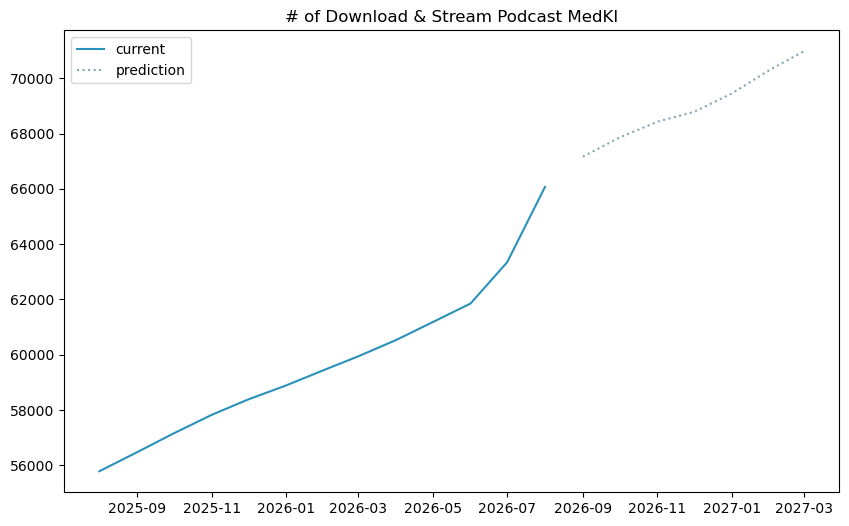

,Podcast_MedKI
Date,
2026-08-01,66069
2026-09-01,67161
2026-10-01,67852
2026-11-01,68426
2026-12-01,68781
2027-01-01,69447
2027-02-01,70298
2027-03-01,70972


In [139]:
# podcast KI medicine

podcast_med_seasonal = fit_monthly_seasonality(podcast_med['Podcast_MedKI'], shrink_k = 6)

for d in pred_moving_average['date']:
    pred = moving_average_scale(podcast_med['Podcast_MedKI'], d.strftime('%Y-%m-%d'), span_years=3, w_year= 0.2, w_3m= 0.20, w_1m= 0.3, decay=0.8, seasonal = podcast_med_seasonal)
    podcast_med.loc[d] = pred
    
podcast_med['Podcast_MedKI'] = [round(x) for x in podcast_med['Podcast_MedKI']]

# plotting
plot_forecast(podcast_med.loc['2025-08-01' : '2026-08-01'], podcast_med.loc['2026-09-01' : ], '# of Download & Stream Podcast MedKI')

podcast_med.loc['2026-08-01' : ]

C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\206388806.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

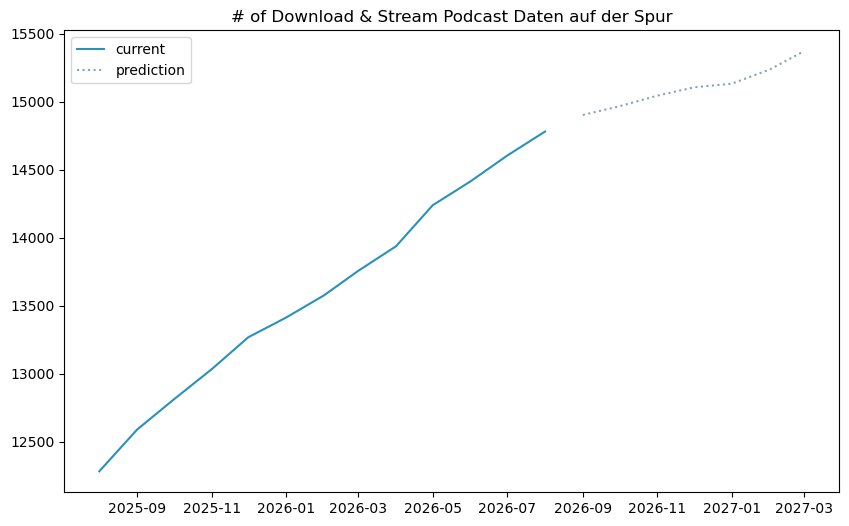

,Podcast_Daten
Date,
2026-08-01,14780
2026-09-01,14902
2026-10-01,14966
2026-11-01,15044
2026-12-01,15105
2027-01-01,15132
2027-02-01,15236
2027-03-01,15370


In [140]:
# podcast data

podcast_daten_seasonal = fit_monthly_seasonality(podcast_daten['Podcast_Daten'], shrink_k = 6)

for d in pred_moving_average['date']:
    pred = moving_average_scale(podcast_daten['Podcast_Daten'], d.strftime('%Y-%m-%d'), span_years=3, w_year= 0.1, w_3m= 0.2, w_1m= 0.3, decay=0.8, seasonal = podcast_daten_seasonal)
    podcast_daten.loc[d] = pred
    
podcast_daten['Podcast_Daten'] = [round(x) for x in podcast_daten['Podcast_Daten']]

# plotting
plot_forecast(podcast_daten.loc['2025-08-01' : '2026-08-01'], podcast_daten.loc['2026-09-01' : ], '# of Download & Stream Podcast Daten auf der Spur')

podcast_daten.loc['2026-08-01' : ]


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\258896729.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6459.7524457544305' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  podcast_journal.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\258896729.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  podcast_journal.loc[d] = pred
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\258896729.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

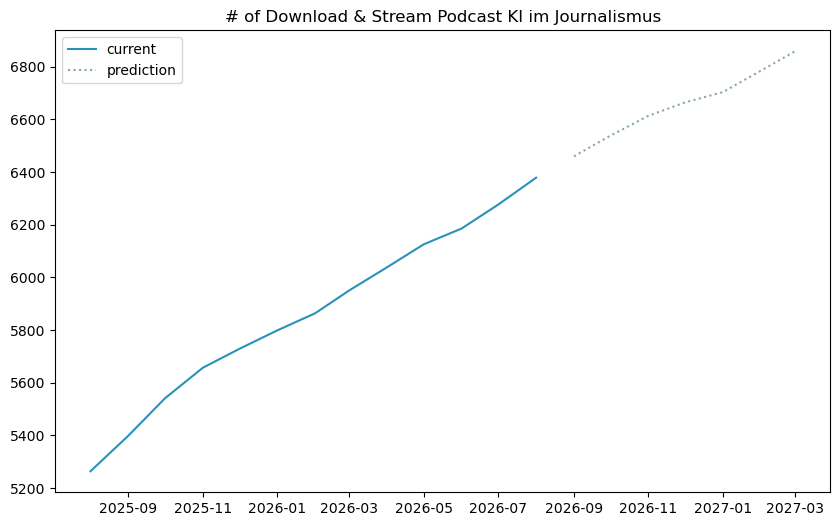

,Podcast_Journalismus
Date,
2026-08-01,6379
2026-09-01,6460
2026-10-01,6539
2026-11-01,6614
2026-12-01,6665
2027-01-01,6704
2027-02-01,6785
2027-03-01,6859


In [143]:
# podcast journalism

podcast_journal_seasonal = fit_monthly_seasonality(podcast_journal['Podcast_Journalismus'], shrink_k = 6)

for d in pred_moving_average['date']:
    pred = moving_average_scale(podcast_journal['Podcast_Journalismus'], d.strftime('%Y-%m-%d'), span_years=3, w_year= 0.2, w_3m= 0.2, w_1m= 0.3, decay=0.7, seasonal = podcast_journal_seasonal)
    podcast_journal.loc[d] = pred
    
podcast_journal['Podcast_Journalismus'] = [round(x) for x in podcast_journal['Podcast_Journalismus']]

# plotting
plot_forecast(podcast_journal.loc['2025-08-01' : '2026-08-01'], podcast_journal.loc['2026-09-01' : ], '# of Download & Stream Podcast KI im Journalismus')

podcast_journal.loc['2026-08-01' : ]


C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\900274538.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r = s.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\2403342588.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  series_pct = series.pct_change().dropna()
C:\Users\ywa\AppData\Local\Temp\ipykernel_22996\3329353853.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

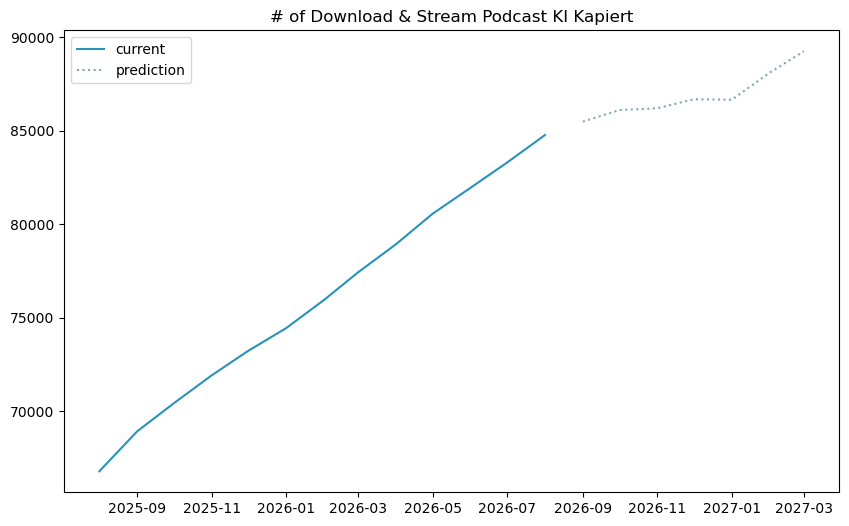

,Podcast_KIKapiert
Date,
2026-08-01,84763
2026-09-01,85478
2026-10-01,86096
2026-11-01,86193
2026-12-01,86675
2027-01-01,86648
2027-02-01,88097
2027-03-01,89238


In [142]:
# podcast KI kapiert

podcast_kapiert_seasonal = fit_monthly_seasonality(podcast_kapiert['Podcast_KIKapiert'], shrink_k = 6)

for d in pred_moving_average['date']:
    pred = moving_average_scale(podcast_kapiert['Podcast_KIKapiert'], d.strftime('%Y-%m-%d'), span_years=3, w_year= 0.05, w_3m= 0.2, w_1m= 0.2, decay=0.7, seasonal = podcast_kapiert_seasonal)
    podcast_kapiert.loc[d] = pred
    
podcast_kapiert['Podcast_KIKapiert'] = [round(x) for x in podcast_kapiert['Podcast_KIKapiert']]

# plotting
plot_forecast(podcast_kapiert.loc['2025-08-01' : '2026-08-01'], podcast_kapiert.loc['2026-09-01' : ], '# of Download & Stream Podcast KI Kapiert')

podcast_kapiert.loc['2026-08-01' : ]

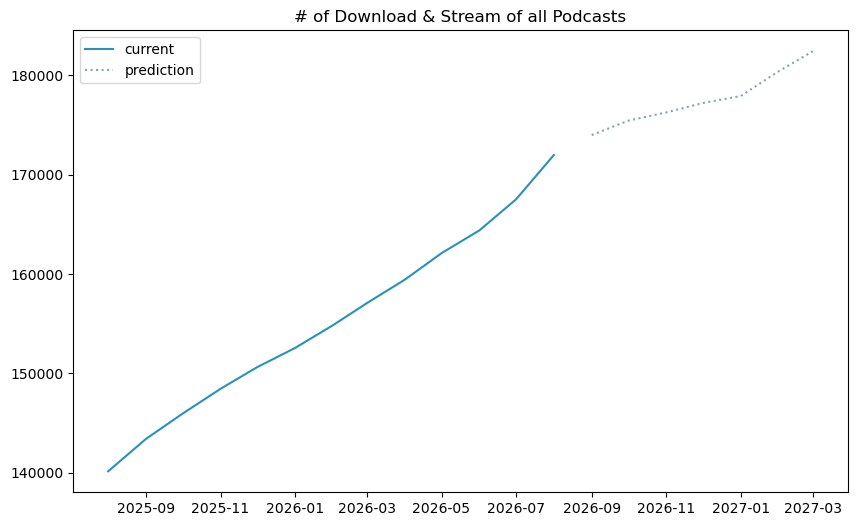

Date
2026-08-01    171991
2026-09-01    174001
2026-10-01    175453
2026-11-01    176277
2026-12-01    177226
2027-01-01    177931
2027-02-01    180416
2027-03-01    182439
dtype: int64

In [148]:
# calcuate sum of the podcast:
podcast_sum = podcast_kapiert['Podcast_KIKapiert'] + podcast_journal['Podcast_Journalismus'] + podcast_daten['Podcast_Daten'] + podcast_med['Podcast_MedKI']
plot_forecast(podcast_sum.loc['2025-08-01' : '2026-08-01'], podcast_sum.loc['2026-09-01' : ], '# of Download & Stream of all Podcasts')

podcast_sum.loc['2026-08-01' : ]

## Moving average method for forecasting (first method)

In [36]:
# Writing function of moving average
def moving_average(series, date_of_interest, span, w1, w2):
    '''
    Computes a weighted moving average prediction based on historical percentage changes.

    This function calculates the expected value of a given time series at a specific 
    date based on its historical percentage changes from previous years and months.

    Parameters:
    ----------
    series : pd.Series
        A pandas Series representing the time series data. The index should be 
        datetime-like (YYYY-MM-DD format), and the values should be numerical.

    date_of_interest : str
        A string representing the date (YYYY-MM-DD) for which the prediction is made.

    span : int
        The number of years to look back for historical trends.

    w1 : float
        The weight applied to the historical yearly percentage change.

    w2 : float
        The weight applied to the historical monthly percentage change.

    Returns:
    -------
    float
        The predicted value of the series for the given `date_of_interest`.

    Notes:
    ------
    - The function calculates percentage changes in the series.
    - It considers both past years' trends and recent months' trends.
    - The prediction is computed using a weighted sum of these historical trends.
    '''
    series_pct = series.pct_change().dropna()
    date_of_interest = datetime.strptime(date_of_interest,'%Y-%m-%d').date()
    previous_month = (date_of_interest - relativedelta(months = 1)).strftime('%Y-%m-%d')
    #year_of_interest = date_of_interest.year --> commented
    #month_of_interest = date_of_interest.month --> commented
    year_indicies = []
    month_indicies = []
    #indexing rate based on the given date --> commented
    for y in range(1, span + 1):
        date_year = (date_of_interest - relativedelta(years = y) + relativedelta(months = 1)).strftime('%Y-%m-%d')
        year_indicies.append(date_year)
        
    for m in range(1, 4, 1):
        date_month = (date_of_interest - relativedelta(months = m)).strftime('%Y-%m-%d')
        month_indicies.append(date_month)
    
    # calculation
    rate_year = series_pct[year_indicies]
    rate_month = series_pct[month_indicies]
    mean_rate_year = rate_year.mean()
    mean_rate_month = rate_month.mean()
    pred_value = series[previous_month] + mean_rate_year * series[previous_month] * w1 + mean_rate_month * series[previous_month] * w2
    #print(series[previous_month]) --> commented
    return pred_value


#### Dynamic weights
* For semester-start months (April, October): w1 = 0.8, w2 = 0.25
* For the semester break months (July, August, September, Febuary, March): w1 = 0.8, w2 = 0.25
* For the regular months: w1 = 0.6 , w2 = 0.4 

In [37]:
# unique visitors

# drop NaNs
unique_visitors.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(unique_visitors['Unique_Visitors'], d, span = 3, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(unique_visitors['Unique_Visitors'], d, span = 3, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(unique_visitors['Unique_Visitors'], d, span = 3, w1 = 0.6, w2 = 0.4)
    unique_visitors.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
unique_visitors['Unique_Visitors'] = [round(x) for x in unique_visitors['Unique_Visitors']]


# plotting
plot_forecast(unique_visitors.loc['2025-01-01' : '2025-12-01'], unique_visitors.loc['2026-01-01' : ], 'Number of Portal Unique Visitors')

# check the rows
unique_visitors.loc['2025-12-01' : ]


C:\Users\ywa\AppData\Local\Temp\ipykernel_10856\1449804804.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_visitors.dropna(inplace = True)


TypeError: strptime() argument 1 must be str, not Timestamp

In [ ]:
# user portal

# drop NaNs
user_portal.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(user_portal['User_Portal'], d, span = 3, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(user_portal['User_Portal'], d, span = 3, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(user_portal['User_Portal'], d, span = 3, w1 = 0.6, w2 = 0.4)
    user_portal.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
user_portal['User_Portal'] = [round(x) for x in user_portal['User_Portal']]


# plotting
plot_forecast(user_portal.loc['2025-01-01' : '2025-12-01'], user_portal.loc['2026-01-01' : ], 'Registered Users on Portal')

# check the rows
user_portal.loc['2025-12-01' : ]


In [ ]:
# User Moodle

# drop NaNs
user_moodle.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(user_moodle['User_Moodle'], d, span = 2, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(user_moodle['User_Moodle'], d, span = 2, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(user_moodle['User_Moodle'], d, span = 2, w1 = 0.6, w2 = 0.4)
    user_moodle.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
user_moodle['User_Moodle'] = [round(x) for x in user_moodle['User_Moodle']]


# plotting
plot_forecast(user_moodle.loc['2025-01-01' : '2025-12-01'], user_moodle.loc['2026-01-01' : ], 'Registered Users on Moodle')

# check the rows
user_moodle.loc['2025-12-01' : ]



In [ ]:
# Moodle enrol

# drop NaNs
enrol_moodle.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(enrol_moodle['Enrolments_Moodle'], d, span = 2, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(enrol_moodle['Enrolments_Moodle'], d, span = 2, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(enrol_moodle['Enrolments_Moodle'], d, span = 2, w1 = 0.6, w2 = 0.4)
    enrol_moodle.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
enrol_moodle['Enrolments_Moodle'] = [round(x) for x in enrol_moodle['Enrolments_Moodle']]


# plotting
plot_forecast(enrol_moodle.loc['2025-01-01' : '2025-12-01'], enrol_moodle.loc['2026-01-01' : ], 'Enrolments on Moodle')

# check the rows
enrol_moodle.loc['2025-12-01' : ]


In [ ]:
# CoP 

# drop NaNs
cop_moodle.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(cop_moodle['CoP_Moodle'], d, span = 2, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(cop_moodle['CoP_Moodle'], d, span = 2, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(cop_moodle['CoP_Moodle'], d, span = 2, w1 = 0.6, w2 = 0.4)
    cop_moodle.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
cop_moodle['CoP_Moodle'] = [round(x) for x in cop_moodle['CoP_Moodle']]


# plotting
plot_forecast(cop_moodle.loc['2025-01-01' : '2025-12-01'], cop_moodle.loc['2026-01-01' : ], '#Acquired Confirmations of Participation')

# check the rows
cop_moodle.loc['2025-12-01' : ]



In [ ]:
# RoA

# drop NaNs
roa_moodle.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(roa_moodle['RoA_Moodle'], d, span = 2, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(roa_moodle['RoA_Moodle'], d, span = 2, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(roa_moodle['RoA_Moodle'], d, span = 2, w1 = 0.6, w2 = 0.4)
    roa_moodle.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
roa_moodle['RoA_Moodle'] = [round(x) for x in roa_moodle['RoA_Moodle']]
#roa_moodle.drop(['CoP_Moodle'], axis = 1, inplace = True)

# plotting
plot_forecast(roa_moodle.loc['2025-01-01' : '2025-12-01'], roa_moodle.loc['2026-01-01' : ], '#Acquired Records of Achievement')

# check the rows

roa_moodle.loc['2025-12-01' : ]



In [ ]:
# Youtube Video View

# drop NaNs
video_youtube.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(video_youtube['Video_Views_YouTube'], d, span = 2, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(video_youtube['Video_Views_YouTube'], d, span = 2, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(video_youtube['Video_Views_YouTube'], d, span = 2, w1 = 0.6, w2 = 0.4)
    video_youtube.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
video_youtube['Video_Views_YouTube'] = [round(x) for x in video_youtube['Video_Views_YouTube']]


# plotting
plot_forecast(video_youtube.loc['2025-01-01' : '2025-12-01'], video_youtube.loc['2026-01-01' : ], '#YouTube Video Views')

# check the rows
video_youtube.loc['2025-12-01' : ]


In [ ]:
# MedKI Podcast stream and download

# drop NaNs
podcast_med.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(podcast_med['Podcast_MedKI'], d, span = 2, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(podcast_med['Podcast_MedKI'], d, span = 2, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(podcast_med['Podcast_MedKI'], d, span = 2, w1 = 0.6, w2 = 0.4)
    podcast_med.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
podcast_med['Podcast_MedKI'] = [round(x) for x in podcast_med['Podcast_MedKI']]


# plotting
plot_forecast(podcast_med.loc['2025-01-01' : '2025-12-01'], podcast_med.loc['2026-01-01' : ], '#Download and Streaming of MedKI Podcast')

# check the rows
podcast_med.loc['2025-12-01' : ]


In [ ]:
# Den Daten af der Spur stream and download

# drop NaNs
podcast_daten.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(podcast_daten['Podcast_Daten'], d, span = 2, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(podcast_daten['Podcast_Daten'], d, span = 2, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(podcast_daten['Podcast_Daten'], d, span = 2, w1 = 0.6, w2 = 0.4)
    podcast_daten.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
podcast_daten['Podcast_Daten'] = [round(x) for x in podcast_daten['Podcast_Daten']]


# plotting
plot_forecast(podcast_daten.loc['2025-01-01' : '2025-12-01'], podcast_daten.loc['2026-01-01' : ], '#Download and Streaming of Daten auf der Spur Podcast')

# check the rows
podcast_daten.loc['2025-12-01' : ]


In [ ]:
# KI im Journalismus stream and download 

# drop NaNs
podcast_journal.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(podcast_journal['Podcast_Journalismus'], d, span = 2, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(podcast_journal['Podcast_Journalismus'], d, span = 2, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(podcast_journal['Podcast_Journalismus'], d, span = 2, w1 = 0.6, w2 = 0.4)
    podcast_journal.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
podcast_journal['Podcast_Journalismus'] = [round(x) for x in podcast_journal['Podcast_Journalismus']]

# plotting
plot_forecast(podcast_journal.loc['2025-01-01' : '2025-12-01'], podcast_journal.loc['2026-01-01' : ], '#Download and Streaming of KI im Journalismus Podcast')

# check the rows
podcast_journal.loc['2025-12-01' : ]



In [ ]:
# KI kapiert stream and download

# drop NaNs
podcast_kapiert.dropna(inplace = True)

# prediction with historical data

for d in pred_moving_average['date']:    
    if datetime.strptime(d,'%Y-%m-%d').month in [4, 10]:
        predictions = moving_average(podcast_kapiert['Podcast_KIKapiert'], d, span = 2, w1 = 0.8, w2 = 0.25)
    elif datetime.strptime(d,'%Y-%m-%d').month in [7, 8, 9, 2, 3]:
        predictions = moving_average(podcast_kapiert['Podcast_KIKapiert'], d, span = 2, w1 = 0.8, w2 = 0.25)
    else: 
        predictions = moving_average(podcast_kapiert['Podcast_KIKapiert'], d, span = 2, w1 = 0.6, w2 = 0.4)
    podcast_kapiert.loc[datetime.strptime(d,'%Y-%m-%d')] = predictions
    
podcast_kapiert['Podcast_KIKapiert'] = [round(x) for x in podcast_kapiert['Podcast_KIKapiert']]

# plotting
plot_forecast(podcast_kapiert.loc['2025-01-01' : '2025-12-01'], podcast_kapiert.loc['2026-01-01' : ], '#Download and Streaming of KI kapiert Podcast')

# check the rows
podcast_kapiert.loc['2025-12-01' : ]

## Second model --> the additive bias contradicts with the cumulative data

In [ ]:
# updated algorithm considering bias, weight and decay
#import numpy as np
#import pandas as pd
#from datetime import datetime
#from dateutil.relativedelta import relativedelta

def moving_average_plus(series, date_of_interest, span_years=3, w_year=0.4, w_3m=0.3, w_1m=0.2, bias=0.0, decay=0.7):
    """
    Enhanced weighted moving-average predictor with bias and momentum terms.
    
    The function calculates the expected value of a given time series at a specific 
    date based on its historical percentage changes from previous years and months.

    Parameters:
    ----------
    series : pd.Series
        A pandas Series representing the time series data. The index should be 
        datetime-like (YYYY-MM-DD format), and the values should be numerical.

    date_of_interest : str
        A string representing the date (YYYY-MM-DD) for which the prediction is made.

    span : int
        The number of years to look back for historical trends.

    w_year : float
        The weight applied to the historical yearly percentage change.

    w_3m : float
        The weight applied to changes from the past three month.
        
    w_1m : float
        The weight applied to changes from the past one month.        

    Returns:
    -------
    float
        The predicted value of the series for the given `date_of_interest`.

    Notes:
    ------
    - The function calculates percentage changes in the series.
    - It considers both past years' trends and recent months' trends.
    - The prediction is computed using a weighted sum with bias and momentum
    """

    series = series.sort_index()
    series_pct = series.pct_change().dropna()

    doi = pd.to_datetime(date_of_interest).normalize()
    prev_month = doi - relativedelta(months=1)

    # --- yearly component ---
    year_dates = [
        doi - relativedelta(years=y) + relativedelta(months=1)
        for y in range(1, span_years + 1)
    ]
    year_rates = series_pct.reindex(year_dates).dropna()

    if len(year_rates) > 0:
        year_weights = np.exp(-decay * np.arange(len(year_rates)))
        year_weights /= year_weights.sum()
        r_year = np.sum(year_rates.values * year_weights)
    else:
        r_year = 0.0

    # --- short-term components ---
    r_1m = series_pct.loc[: prev_month].iloc[-1]

    last_3m = [
        doi - relativedelta(months=m) for m in range(1, 4)
    ]
    r_3m_vals = series_pct.reindex(last_3m).dropna()
    r_3m = r_3m_vals.mean() if len(r_3m_vals) > 0 else 0.0

    # --- prediction ---
    base = series.loc[: prev_month].iloc[-1]
    if pd.isna(base):
        raise KeyError(f"Previous month {prev_month.date()} not in series index.")
    growth = (
        w_year * r_year +
        w_3m * r_3m +
        w_1m * r_1m
    )

    pred = base * (1 + growth) + bias
    return pred

In [ ]:

# claculate bias term based on the data from 2024-12-01 to 2026-01-01

unique_visitors_bias = bias_calculator(unique_visitors)

print(unique_visitors_bias)

user_portal_bias = bias_calculator(user_portal)

user_moodle_bias = bias_calculator(user_moodle)

enrol_moodle_bias = bias_calculator(enrol_moodle)

cop_moodle_bias = bias_calculator(cop_moodle)

roa_moodle_bias = bias_calculator(roa_moodle)

video_youtube_bias = bias_calculator(video_youtube)

podcast_med_bias = bias_calculator(podcast_med)

podcast_daten_bias = bias_calculator(podcast_daten)

podcast_journal_bias = bias_calculator(podcast_journal)

podcast_kapiert_bias = bias_calculator(podcast_kapiert)
    

Bias did not work well with the precdiction as the data is culmalative. Instead of adding bias term, add scale factor instead.

In [ ]:
# scale factor calculator --> k = median(y / y_hat)

def scalefactor_calculator(df):
    factors = []

    # only slice the ts that is outside the backtest time stamps (other wise the pct will be calculated)

    df_copy = df.copy().iloc[:, 0]

    for t in backtest['date']:
        prev = t - relativedelta(month = 1)
    
        train = df_copy.loc[: prev]
    
        y_true = df_copy.reindex([t]).iloc[0]
    
        if train.empty or pd.isna(y_true):
            continue
        y_hat = moving_average_plus(train, t.strftime('%Y-%m-%d'), span_years = 3, w_year=0.4, w_3m=0.3, w_1m=0.2, bias=0.0, decay=0.7)
        factors.append(y_true / y_hat)

    median_factors = np.median(factors)
    
    return avg_errors

In [ ]:

#unique_visitors = kpi_df[['Unique_Visitors']]

#user_portal = kpi_df[['User_Portal']]

#user_moodle = kpi_df[['User_Moodle']]

#enrol_moodle = kpi_df[['Enrolments_Moodle']]

#cop_moodle = kpi_df[['CoP_Moodle']]

#roa_moodle = kpi_df[['RoA_Moodle']]

#video_youtube = kpi_df[['Video_Views_YouTube']]

#podcast_med = kpi_df[['Podcast_MedKI']]

#podcast_daten = kpi_df[['Podcast_Daten']]

#podcast_journal = kpi_df[['Podcast_Journalismus']]

#podcast_kapiert = kpi_df[['Podcast_KIKapiert']]



In [ ]:
# prediction with bias term -- unique visitors

pred_moving_average['date'] = pd.to_datetime(pred_moving_average['date'])

# drop NaNs
unique_visitors.dropna(inplace = True)

preds = []

for d in pred_moving_average['date']:
    pred = moving_average_plus(unique_visitors['Unique_Visitors'], d.strftime('%Y-%m-%d'), span_years=3, w_year=0.4, w_3m=0.3, w_1m=0.2, bias= 0, decay=0.7)
    unique_visitors.loc[d] = pred
    
unique_visitors['Unique_Visitors'] = [round(x) for x in unique_visitors['Unique_Visitors']]

# plotting
plot_forecast(unique_visitors.loc['2025-01-01' : '2026-01-01'], unique_visitors.loc['2026-02-01' : ], '# of Unique Visitors on Portal')

unique_visitors


## EDA section

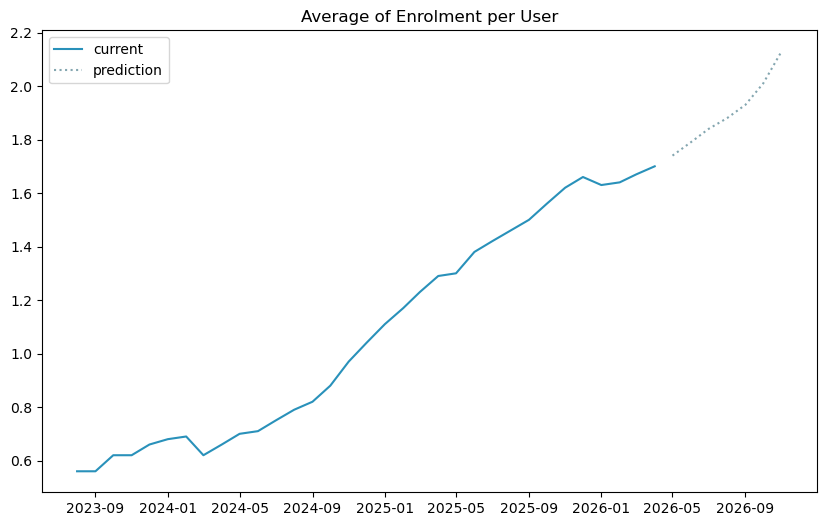

,per_user
Date,
2023-08-01,0.56
2023-09-01,0.56
2023-10-01,0.62
2023-11-01,0.62
2023-12-01,0.66
2024-01-01,0.68
2024-02-01,0.69
2024-03-01,0.62
2024-04-01,0.66


In [39]:
# enrolment per person on Moodle

enrol_per_user = pd.DataFrame()

enrol_per_user['per_user'] =  enrol_moodle['Enrolments_Moodle'] / user_moodle['User_Moodle']

enrol_per_user['per_user'] = [round(x, 2) for x in enrol_per_user['per_user']]

plot_forecast(enrol_per_user.loc[: '2026-04-01'], enrol_per_user.loc['2026-05-01' : ], 'Average of Enrolment per User')

enrol_per_user